### Baby copilot graph
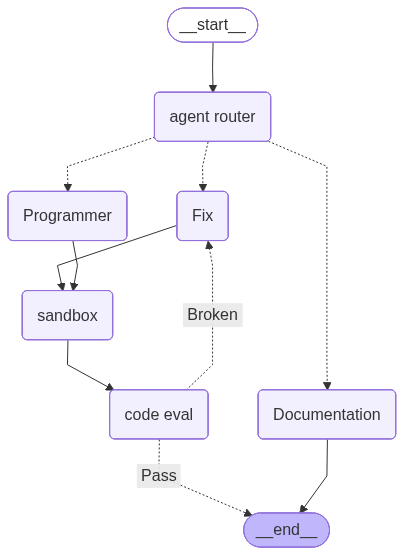 

<!-- docker build -t ai-sandbox:py311 -f sandbox/Dockerfile sandbox -->

#### ENV Setup only need GOOGLE_API_KEY for gemini usage

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

### Prompts and prompt template

In [ ]:
from langchain.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage,SystemMessage

CODE_AGENT_SYSTEM_PROMPT = """
You are a highly experienced Senior Software Engineer with deep expertise in software architecture, clean code design, and scalable system development.
Your responsibilities include:
1. Designing robust, maintainable, and scalable architectures across multiple domains (web, backend, mobile, cloud).
2. Writing production-quality code that follows best practices in readability, performance, and security.
3. Applying strong debugging and troubleshooting skills: analyze error logs, stack traces, and faulty outputs; identify root causes; and provide precise fixes.
4. Offering clear explanations of why issues occur and suggesting preventive improvements.
5. Following principles such as SOLID, DRY, KISS, and clean architecture, while also considering performance, scalability, and fault tolerance.
6. Evaluating trade-offs between different design choices and recommending the most suitable approach.

When responding:
1. Provide step-by-step reasoning for debugging.
2. Suggest alternative approaches if relevant.
3. Write code that is well-structured, tested, and ready for real-world use.
4. Keep explanations clear and concise, as if mentoring a mid-level developer.

Always return in this format:
    code:str // Base code DO NOT Add Examples or print statement 
    description: // a small docx
    metadata: // input and output of the code
    example:str // example with Print statement for showing actual output
    expected_output:str // expected output
    requirements: List[str] // list of libraries used in code (only mention which need to install not available by default) set [] if nothing required

AND MOST IMPORTANT IN EXAMPLE USE PRINT STATEMENT so we can compare the std output (console logs) with expected_output

Always act as a reliable senior engineer who not only delivers fixes but also teaches best practices so that the developer can avoid similar issues in the future.
"""

DOCX_AGENT_SYSTEM_PROMPT = """
You are a professional technical writer. You will be given input parameters with their descriptions, 
and your task is to generate a clear, well-structured .docx document content. 

The document should include:
1. A title page with the document name.
2. A structured introduction.
3. A detailed section for each input parameter:
   - Parameter name
   - Description
   - Example usage (code or data snippet)
4. A summary section with key takeaways.

Input Parameters:


Expected Response:
- A formatted outline of the document content (headings, subheadings, and text).
- Clear explanations that are concise and professional.
- Include examples where appropriate.
"""

FIX_PROMPT = """
You are a Senior Software Engineer. You will be given a code snippet and an error detail. 
Your task is to:
1. Analyze the error and explain the root cause clearly.
2. Provide step-by-step instructions on how to fix it.

Code:
{code}

Error:
{error}
"""

fix_code_prompt_template = ChatPromptTemplate.from_messages([
    SystemMessage(CODE_AGENT_SYSTEM_PROMPT),
    HumanMessage(FIX_PROMPT)
])


In [79]:
from typing import Annotated,List,TypedDict,Literal

from langchain_google_genai.chat_models import ChatGoogleGenerativeAI
from langchain_core.pydantic_v1 import BaseModel,Field
from langgraph.graph import START,END,StateGraph
# from langchain_sandbox import PyodideSandboxTool
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,AIMessage,SystemMessage,HumanMessage
from sandbox.executor.docker_runner import run_code_in_sandbox
from langchain_core.tools import tool

# App Settings LLM 
BASE_MODEL = 'gemini-2.5-pro'
MAX_FIX_COUNT = 3 # Maximum retries to fix a code

# Workflow Condition mapper
AGENTS = ["Fix","Programmer","Documentation"]
CODE_RESULTS = ["Pass","Failed","Broken"]


# Docker Sandbox tool wrapper
def sandbox_tool(code:str,requirements:List=[],env_vars:dict={}):
    """
    Tool to execute ai generated code in docker sandbox,
    it takes code,requirement and env variables and execute in separated env via docker and
    returns the std out, err and static file location 
    it also streams the execution logs
    """
    for i in run_code_in_sandbox(code, requirements=requirements,stream=True,network=True,env_vars=env_vars):
        yield i

# --------------------------------------------------------------------------
# LLM Structural Output classes
class ToolCodeOutputStructure(BaseModel):
    code:str
    description:str
    metadata:str
    example:str
    expected_output:str
    requirements: List[str]
    # env_vars: dict

class CodeQueryRoute(BaseModel):
    f"Route a programmer to the following agents {",".join(AGENTS)}"
    agent:Literal["Fix","Programmer","Documentation"] = Field(...,description=f"From the given user query, select which agent is appropriate out of the following agent option {",".join(AGENTS)}")

class CodeTestEvaluator(BaseModel):
    f"From the give result/output/stdio console output of code execution evaluate {",".join(CODE_RESULTS)}"
    result:Literal["Pass","Failed","Broken"] = Field(...,description=f"From the give result/output/stdio console output of code execution evaluate {",".join(CODE_RESULTS)}")

# -------------------------------------------------------------
# Workflow State

class State(TypedDict):
    # code agent
    code:str
    docs:dict
    example:str
    expected_output:str
    requirements: List[str]

    # fix agent
    std_out:str

    # docx agent
    complete_docs:str

    # app state
    messages:Annotated[List[BaseMessage],add_messages]
    current_agent:str
    test_result:Literal["Pass","Failed","Broken"]
    fix_counts:int
    


# Base Chat model
def get_chat_model(model = BASE_MODEL,temperature=.7,type="gemini"):
    if type == "gemini":
        return ChatGoogleGenerativeAI(model=BASE_MODEL,temperature=temperature)
    return None

# Node Models
generic_model = get_chat_model()
model_with_code_gen_structure = get_chat_model(temperature=0).with_structured_output(ToolCodeOutputStructure)
query_agent_router = get_chat_model(temperature=0).with_structured_output(CodeQueryRoute)
code_test_evaluator = get_chat_model(temperature=0).with_structured_output(CodeTestEvaluator)


# Node Definitions
def code_node(state:State) -> State:
    res = model_with_code_gen_structure.invoke([SystemMessage(CODE_AGENT_SYSTEM_PROMPT), state['messages'][0]])
    return {
        "code":res.code,
        "docs":{
                "description":res.description,
                "metadata":res.metadata
                },
        "example":res.example,
        "expected_output":res.expected_output,
        "requirements":res.requirements,
        # "env_vars":res.env_vars
        }

def fix_node(state:State) -> State:
    fix_chain = fix_code_prompt_template | generic_model 
    res = fix_chain.invoke({"code":state['code'],"error":state['std_out']})
    struct_res = model_with_code_gen_structure.invoke(res.content)
    return {
        'messages':[res],
        "code":struct_res.code,
        "docs": {
                "description":struct_res.description,
                "metadata":struct_res.metadata
                },
        "example":struct_res.example,
        "expected_output":struct_res.expected_output,
        "requirements":struct_res.requirements,
        # "env_vars":struct_res.env_vars
        }

def docs_node(state:State) -> State:
    docs_prompt = """Here is the Code : {code}"""
    docs_prompt_template = ChatPromptTemplate.from_messages([SystemMessage(DOCX_AGENT_SYSTEM_PROMPT),HumanMessage(docs_prompt)])
    docs_chain = docs_prompt_template | generic_model
    res = docs_chain.invoke({"code":state['code']})
    return {"complete_docs":res.content}

def query_router(state:State):
    res = query_agent_router.invoke(state["messages"])
    return {"current_agent":res.agent}

def code_test_eval(state:State):
    res = code_test_evaluator.invoke(state['std_out'])
    if res.result != "Pass":
        count = state.get("fix_counts",0) + 1
        return {"test_result":res.result,"fix_counts":count}
    return {"test_result":res.result,"fix_counts":0}

def agent_picker(state:State)-> Literal["Fix","Programmer","Documentation"]:
    return state['current_agent']

def execution_result_eval(state:State)-> Literal["Pass","Failed","Broken","Terminate"]:
    if state.get("fix_counts",0) > MAX_FIX_COUNT:
        return "Terminate"
    return state['test_result']

def sandbox_node(state: State) -> State:
    code_to_run = state.get("code","") + "\n" + state.get("example","")

    # Run inside sandbox
    for i in sandbox_tool(code_to_run,state.get("requirements",[]),state.get("env_vars",{})):
        pass
    
    temp_file,std_out,std_err = i 
    print("LOG",i,code_to_run,state)

    return {
        # "std_out": res.get("stdout", ""),
        "std_out": std_out+std_err,
    }


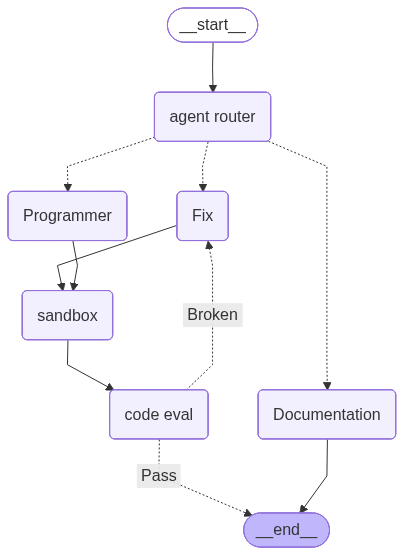

In [80]:
builder = StateGraph(State)
builder.add_node("Programmer",code_node)
builder.add_node("Fix",fix_node)
builder.add_node("Documentation",docs_node)
builder.add_node("agent router",query_router)
builder.add_node("sandbox",sandbox_node)
builder.add_node("code eval",code_test_eval)

builder.add_edge(START,'agent router')
builder.add_conditional_edges("agent router",agent_picker)
builder.add_edge('Fix','sandbox')
builder.add_edge('Programmer','sandbox')
builder.add_edge('sandbox','code eval')
builder.add_conditional_edges("code eval", execution_result_eval, {
    "Pass": END,
    "Failed": "Fix",      # send back to fixer
    "Broken": "Fix",  # maybe restart programming
    "Terminate":END
})
builder.add_edge('Documentation',END)

graph = builder.compile()
graph

## Basic Example I 

In [48]:
for i in graph.stream({'messages':HumanMessage("write code to add two numbers")}):
    print(i)

{'agent router': {'current_agent': 'Programmer'}}
{'Programmer': {'code': 'def add(a, b):\n    return a + b', 'docs': {'description': 'This code defines a function called `add` that takes two numbers, `a` and `b`, as input and returns their sum.', 'metadata': ''}, 'example': 'print(add(5, 3))', 'expected_output': '8', 'requirements': [], 'env_vars': {}}}
LOG ('C:\\Users\\jeetc\\AppData\\Local\\Temp\\job_4n6jzszx_out', '8\n', '') def add(a, b):
    return a + b
print(add(5, 3)) {'code': 'def add(a, b):\n    return a + b', 'docs': {'description': 'This code defines a function called `add` that takes two numbers, `a` and `b`, as input and returns their sum.', 'metadata': ''}, 'example': 'print(add(5, 3))', 'expected_output': '8', 'requirements': [], 'env_vars': {}, 'messages': [HumanMessage(content='write code to add two numbers', additional_kwargs={}, response_metadata={}, id='9f3bf65a-1471-4b69-a2cb-2e9972cb91e8')], 'current_agent': 'Programmer'}
{'sandbox': {'std_out': '8\n'}}
{'code e

## Example - II Weather Tool

In [ ]:
for i in graph.stream({'messages':HumanMessage("write program to get the weather data of Canada toronto without api key")},):
    print(i)

{'agent router': {'current_agent': 'Programmer'}}
{'Programmer': {'code': 'import requests\n\ndef get_weather_data(city):\n    url = f"https://wttr.in/{city}?format=%C+%t"\n    try:\n        response = requests.get(url)\n        response.raise_for_status()  # Raise HTTPError for bad responses (4xx or 5xx)\n        weather_data = response.text.strip()\n        return weather_data\n    except requests.exceptions.RequestException as e:\n        return f"Error fetching weather data: {e}"\n\n\ncity_name = "Toronto"\nweather_info = get_weather_data(city_name)\nprint(f"Weather in {city_name}: {weather_info}")', 'docs': {'description': 'This code retrieves weather information for a specified city using the wttr.in service, which provides weather data through a simple HTTP request. The function `get_weather_data` constructs the URL, makes the request, and returns the weather information in text format. Error handling is included to catch potential issues during the request process. The code the

## Complex example with tread or chat memory

In [74]:
from uuid import uuid4

def generate_tool(query):
    thread_id = uuid4().__str__()
    thread = {"configurable": {"thread_id": thread_id}}
    try:
        for i in graph.stream({'messages':HumanMessage(query)},thread):
            print(i)
    except Exception as e:
        print(e)
    return thread


In [71]:
t = generate_tool("Write program to get top news without an api key")

{'agent router': {'current_agent': 'Programmer'}}
{'Programmer': {'code': '\nimport feedparser\n\ndef get_top_news(limit=5):\n    """\n    Fetches the top news headlines from Google News RSS feed.\n\n    This function retrieves the latest news articles without needing an API key by parsing\n    the public Google News RSS feed. It is designed to be simple and efficient for\n    quick access to top stories.\n\n    Args:\n        limit (int): The maximum number of news articles to return. Defaults to 5.\n\n    Returns:\n        list: A list of dictionaries, where each dictionary represents a news article\n              with \'title\', \'link\', and \'published\' keys. Returns an empty list\n              if the feed cannot be fetched or parsed.\n    """\n    # Google News RSS feed URL for top stories\n    url = "https://news.google.com/rss?hl=en-US&gl=US&ceid=US:en"\n    \n    try:\n        # Parse the RSS feed\n        feed = feedparser.parse(url)\n        \n        # Check if the feed w

In [ ]:
graph.get_state(t)

## Docker Sandbox Tool Example 

In [13]:
import subprocess
import tempfile
import os

def run_in_docker(code: str):
    with tempfile.TemporaryDirectory() as tmpdir:
        script_path = os.path.join(tmpdir, "script.py")
        with open(script_path, "w") as f:
            f.write(code)

        result = subprocess.run(
            [
                "docker", "run", "--rm",
                "-v", f"{tmpdir}:/app",   # mount temp dir as /app
                "-w", "/app",             # set working directory
                "python:3.11-slim",       # docker image
                "python", "script.py"     # run our script
            ],
            capture_output=True,
            text=True
        )
        return result.stdout, result.stderr

# Test
stdout, stderr = run_in_docker('print("test")')
print("STDOUT:", stdout)
print("STDERR:", stderr)


STDOUT: test

STDERR: 


In [5]:
from sandbox.executor.docker_runner import run_code_in_sandbox
code = """
import matplotlib.pyplot as plt
print("Hello from sandbox")
plt.plot([1,2,3],[1,4,9])
plt.savefig("out/plot.png")
"""
for i in run_code_in_sandbox(code, requirements=["matplotlib"],stream=True,network=True):
    print(i)


STDOUT Collecting matplotlib (from -r requirements.txt (line 1))
STDOUT   Downloading matplotlib-3.10.5-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
STDOUT Collecting contourpy>=1.0.1 (from matplotlib->-r requirements.txt (line 1))
STDOUT   Downloading contourpy-1.3.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
STDOUT Collecting cycler>=0.10 (from matplotlib->-r requirements.txt (line 1))
STDOUT   Downloading cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
STDOUT Collecting fonttools>=4.22.0 (from matplotlib->-r requirements.txt (line 1))
STDOUT   Downloading fonttools-4.59.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (108 kB)
STDOUT      ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.9 MB/s eta 0:00:00
STDOUT Collecting kiwisolver>=1.3.1 (from matplotlib->-r requirements.txt (line 1))
STDOUT   Downloading kiwisolver-1.4.9-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metad